In [1]:
import os
os.environ["PKG_CONFIG_PATH"] = "/home/jaeyonglee/anaconda3/envs/fenics/lib/pkgconfig"

In [2]:
import numpy as np
import scipy
from scipy import io
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
import torch

In [3]:
import dolfin
from dolfin import *
from mshr import *

/home/hongyj/miniconda3/envs/feonet/lib/python3.10/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/hongyj/miniconda3/envs/feonet/lib/python3.10/site-packages/dolfin/jit/jit.py:121: RuntimeWarning: mpi4py.MPI.Session size changed, may indicate binary incompatibility. Expected 32 from C header, got 40 from PyObject
  def compile_class(cpp_data, mpi_comm=MPI.comm_world):


Setting num :15 // Num Element : 712


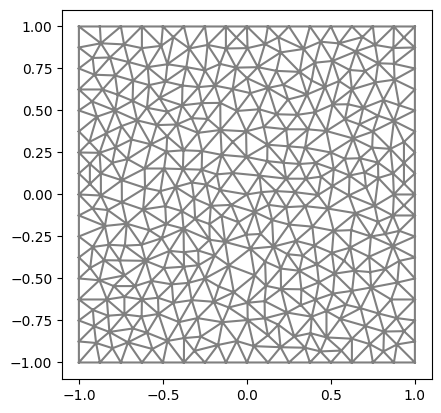

In [4]:
num=15
domain = Rectangle(Point(-1,-1), Point(1,1))
mesh = generate_mesh(domain, num)
plot(mesh)
print("Setting num :{} // Num Element : {}".format(num, mesh.cells().shape[0]))

In [5]:
# Preconditioning
from scipy.sparse import identity
from scipy.sparse import diags
from scipy.sparse.linalg import onenormest

def spai(A, m):
    """Perform m step of the SPAI iteration."""

    n = A.shape[0]

    ident = identity(n, format='csr')
    alpha = 2 / onenormest(A @ A.T)
    M = alpha * A

    for index in tqdm(range(m)):
        C = A @ M
        G = ident - C
        AG = A @ G
        trace = (G.T @ AG).diagonal().sum()
        alpha = trace / np.linalg.norm(AG.data)**2
        M = M + alpha * G

    return M

In [6]:
def fenics_mesh(num_xy, num_input, deg_v, save_precond, deg_f=5):
    domain = Rectangle(Point(-1, -1), Point(1, 1))
    mesh = generate_mesh(domain, num_xy)

    V = FunctionSpace(mesh, "DG", deg_v)

    u = TrialFunction(V)
    v = TestFunction(V)

    # Geometry
    n = FacetNormal(mesh)
    h = CellDiameter(mesh)
    h_avg = (h('+') + h('-')) / 2.0
    alpha = Constant(5.0 * (1 + 1)**2)

    # Step 1: Define DG function space
    V_eps = FunctionSpace(mesh, 'DG', 0)
    #eps_expr = Constant(1e-6)
    #eps_expr = Expression('x[0] < 0 ? 0.01 : 0.1', degree=0)
    eps_expr = Expression('sqrt(x[0]*x[0] + x[1]*x[1]) < r0 ? eps_inside : eps_outside',
                          degree=0, r0=0.5, eps_inside=0.1, eps_outside=2.0)

    # Step 3: Project it to a function
    eps_proj = project(eps_expr, V_eps)

    # Exact solution and source
    u_D_expr = Constant(0.0)
    #f = Constant(-4.0)
    g = u_D_expr
    b_vec = Constant((-1.0, 0.0))
    beta_int = dot(b_vec, n('+'))
    beta_bnd = dot(b_vec, n)
    conv_vol = dot(b_vec, grad(u)) * v * dx
    conv_flux_int = -(beta_int * avg(u) + Constant(0.5) * abs(beta_int) * jump(u)) * jump(v) * dS
    conv_flux_bnd = -conditional(ge(beta_bnd, 0.0), beta_bnd * u * v, 0.0) * ds

    # SIPG bilinear form
    a = (
        eps_proj*dot(grad(u), grad(v)) * dx
        - dot(avg(eps_proj*grad(u)), jump(v, n)) * dS
        - dot(avg(eps_proj*grad(v)), jump(u, n)) * dS
        + avg(eps_proj)*alpha / h_avg * dot(jump(u, n), jump(v, n)) * dS
        - eps_proj*dot(grad(u), v * n) * ds
        - eps_proj*dot(grad(v), u * n) * ds
        + eps_proj*alpha / h * u * v * ds+ conv_vol+ conv_flux_int+ conv_flux_bnd
    )





    A = PETScMatrix()
    A = assemble(a)
    stiff = A.array()

    if save_precond:
        precond = spai(stiff, 20)
        print(np.linalg.cond(stiff))
        print(np.linalg.cond(stiff @ precond))
    else:
        precond = torch.zeros(stiff.shape)

    train_coeff_fs = []
    train_load_vectors = []
    #r0 = 0.5 

    np.random.seed(5)
    for _ in range(num_input[0]):
        m0, m1 = 1 + np.random.rand(2)
        n0, n1, n2, n3 = np.pi * np.random.rand(4)
        f = Expression('m0*sin(n0*x[0]+n1*x[1]) + m1*cos(n2*x[0]+n3*x[1])',
                       degree=deg_f, m0=m0, m1=m1, n0=n0, n1=n1, n2=n2, n3=n3)
        #f = Expression('2*pi*pi*sin(pi*x[0])*sin(pi*x[1])',degree=3, pi=np.pi)

        l = f * v * dx+ alpha / h * g * v * ds- dot(grad(v), g * n) * ds
        L = assemble(l)
        load_vector = L.get_local()
        train_coeff_fs.append(np.array([m0, m1, n0, n1, n2, n3]))
        train_load_vectors.append(load_vector)

    validate_coeff_fs = []
    validate_load_vectors = []

    np.random.seed(10)
    for _ in range(num_input[1]):
        m0, m1 = 1 + np.random.rand(2)
        n0, n1, n2, n3 = np.pi * np.random.rand(4)
        f = Expression('m0*sin(n0*x[0]+n1*x[1]) + m1*cos(n2*x[0]+n3*x[1])',
                       degree=deg_f, m0=m0, m1=m1, n0=n0, n1=n1, n2=n2, n3=n3)
        #f = Expression('2*pi*pi*sin(pi*x[0])*sin(pi*x[1])',degree=3, pi=np.pi)
        l = f * v * dx+ alpha / h * g * v * ds- dot(grad(v), g * n) * ds
        L = assemble(l)
        load_vector = L.get_local()
        validate_coeff_fs.append(np.array([m0, m1, n0, n1, n2, n3]))
        validate_load_vectors.append(load_vector)

    ne = mesh.num_cells()
    dofmap = V.dofmap()
    p = V.tabulate_dof_coordinates()
    ng = p.shape[0]

    c = []
    for i in range(ne):
        c.append(dofmap.cell_dofs(i))
    c = np.asarray(c)

    gfl = np.zeros((ng))  # No boundary points flagged for DG

    print("Num of Elements : {}, Num of points : {}".format(ne, ng))
    return ne, ng, p, c, gfl, stiff, precond, np.array(train_coeff_fs), np.array(train_load_vectors), np.array(validate_coeff_fs), np.array(validate_load_vectors)


In [7]:
order=1
list_num_xy=[15]
num_input=[100, 100]
save_precond=[True,False]
typ='circlehole' 

In [8]:
import os
os.makedirs("mesh", exist_ok=True)  # Ensure the directory exists

list_ne=[]

for idx, num in enumerate(list_num_xy):
  ne, ng, p, c,  gfl,stiff, precond, train_coeff_fs, train_load_vectors, validate_coeff_fs, validate_load_vectors=fenics_mesh(num, num_input, order, save_precond[idx])
  np.savez('mesh/P{}_ne{}_{}.npz'.format(order,ne,typ),ne=ne,ng=ng,p=p,c=c,gfl=gfl,stiff=stiff,precond=precond,train_coeff_fs=train_coeff_fs, train_load_vectors=train_load_vectors, validate_coeff_fs=validate_coeff_fs, validate_load_vectors=validate_load_vectors)
  list_ne.append(ne)
print(list_ne)

/home/hongyj/miniconda3/envs/feonet/lib/python3.10/site-packages/dolfin/jit/jit.py:46: RuntimeWarning: mpi4py.MPI.Session size changed, may indicate binary incompatibility. Expected 32 from C header, got 40 from PyObject
  if MPI.size(mpi_comm) == 1:
100%|███████████████████████████████████████████| 20/20 [00:05<00:00,  3.46it/s]


17636.826564406514
933.3258315317632
Num of Elements : 712, Num of points : 2136
[712]


In [9]:
def fenics_data(num_xy, num_input, deg_v, deg_f=5):
  # Set solver parameters to suppress output
  parameters["std_out_all_processes"] = False  # Suppress output for parallel runs
  set_log_level(LogLevel.ERROR)  # Suppress solver logs
  
  domain = Rectangle(Point(-1,-1), Point(1,1))
  mesh = generate_mesh(domain, num_xy)
  V = FunctionSpace(mesh, "DG", deg_v)

  u = TrialFunction(V)
  v = TestFunction(V)
  #r0 = 0.5

  train_fenics_u=[]
  np.random.seed(5)
  for i in range(num_input[0]):
    u = TrialFunction(V)
    v = TestFunction(V)
    # Geometry
    n = FacetNormal(mesh)
    h = CellDiameter(mesh)
    h_avg = (h('+') + h('-')) / 2.0
    alpha = Constant(5.0 * (1 + 1)**2)

    # Exact solution and source
    u_D_expr = Constant(0.0)
    #f = Constant(-4.0)
    g = u_D_expr

    # Step 1: Define DG function space
    V_eps = FunctionSpace(mesh, 'DG', 0)
    eps_expr = Expression('sqrt(x[0]*x[0] + x[1]*x[1]) < r0 ? eps_inside : eps_outside',
                          degree=0, r0=0.5, eps_inside=0.1, eps_outside=2.0)
    

    # Step 3: Project it to a function
    eps_proj = project(eps_expr, V_eps)
    b_vec = Constant((-1.0, 0.0))
    beta_int = dot(b_vec, n('+'))
    beta_bnd = dot(b_vec, n)
    conv_vol = dot(b_vec, grad(u)) * v * dx
    conv_flux_int = -(beta_int * avg(u) + Constant(0.5) * abs(beta_int) * jump(u)) * jump(v) * dS
    conv_flux_bnd = -conditional(ge(beta_bnd, 0.0), beta_bnd * u * v, 0.0) * ds

    # SIPG bilinear form
    # SIPG bilinear form
    a = (
        eps_proj*dot(grad(u), grad(v)) * dx
        - dot(avg(eps_proj*grad(u)), jump(v, n)) * dS
        - dot(avg(eps_proj*grad(v)), jump(u, n)) * dS
        + avg(eps_proj)*alpha / h_avg * dot(jump(u, n), jump(v, n)) * dS
        - eps_proj*dot(grad(u), v * n) * ds
        - eps_proj*dot(grad(v), u * n) * ds
        + eps_proj*alpha / h * u * v * ds+ conv_vol+ conv_flux_int+ conv_flux_bnd
    ) 



    

    m0, m1 = 1 + np.random.rand(2)
    n0, n1, n2, n3 = np.pi*(np.random.rand(4))
    f =Expression('m0*sin(n0*x[0]+n1*x[1]) + m1*cos(n2*x[0]+n3*x[1])', degree=deg_f, m0=m0,m1=m1,n0=n0,n1=n1,n2=n2,n3=n3)
    #f = Expression('2*pi*pi*sin(pi*x[0])*sin(pi*x[1])',degree=3, pi=np.pi)
    l = f * v * dx+ alpha / h * g * v * ds- dot(grad(v), g * n) * ds

    u = Function(V)
    solve(a == l, u)
    fenics_u = u.vector().get_local()

    p = V.tabulate_dof_coordinates()
    train_fenics_u.append([fenics_u, m0*np.sin(n0*p[:,0]+n1*p[:,1]) + m1*np.cos(n2*p[:,0]+n3*p[:,1]), np.array([m0, m1, n0, n1, n2, n3])])

  validate_fenics_u=[]
  np.random.seed(10)
  for i in range(num_input[1]):
    u = TrialFunction(V)
    v = TestFunction(V)

    # Geometry
    n = FacetNormal(mesh)
    h = CellDiameter(mesh)
    h_avg = (h('+') + h('-')) / 2.0
    alpha = Constant(5.0 * (1 + 1)**2)

    # Exact solution and source
    u_D_expr = Constant(0.0)
    #f = Constant(-4.0)
    g = u_D_expr

    # Step 1: Define DG function space
    V_eps = FunctionSpace(mesh, 'DG', 0)
    eps_expr = Expression('sqrt(x[0]*x[0] + x[1]*x[1]) < r0 ? eps_inside : eps_outside',
                          degree=0, r0=0.5, eps_inside=0.1, eps_outside=2.0)
    
    # Step 3: Project it to a function
    eps_proj = project(eps_expr, V_eps)

    # SIPG bilinear form
    b_vec = Constant((-1.0, 0.0))
    beta_int = dot(b_vec, n('+'))
    beta_bnd = dot(b_vec, n)
    conv_vol = dot(b_vec, grad(u)) * v * dx
    conv_flux_int = -(beta_int * avg(u) + Constant(0.5) * abs(beta_int) * jump(u)) * jump(v) * dS
    conv_flux_bnd = -conditional(ge(beta_bnd, 0.0), beta_bnd * u * v, 0.0) * ds
    # SIPG bilinear form
    a = (
        eps_proj*dot(grad(u), grad(v)) * dx
        - dot(avg(eps_proj*grad(u)), jump(v, n)) * dS
        - dot(avg(eps_proj*grad(v)), jump(u, n)) * dS
        + avg(eps_proj)*alpha / h_avg * dot(jump(u, n), jump(v, n)) * dS
        - eps_proj*dot(grad(u), v * n) * ds
        - eps_proj*dot(grad(v), u * n) * ds
        + eps_proj*alpha / h * u * v * ds+ conv_vol+ conv_flux_int+ conv_flux_bnd
    )



    

    m0, m1 = 1 + np.random.rand(2)
    n0, n1, n2, n3 = np.pi*(np.random.rand(4))
    f =Expression('m0*sin(n0*x[0]+n1*x[1]) + m1*cos(n2*x[0]+n3*x[1])', degree=deg_f, m0=m0,m1=m1,n0=n0,n1=n1,n2=n2,n3=n3)
    #f = Expression('2*pi*pi*sin(pi*x[0])*sin(pi*x[1])',degree=3, pi=np.pi)
    l = f * v * dx+ alpha / h * g * v * ds- dot(grad(v), g * n) * ds

    u = Function(V)
    solve(a == l,u)
    fenics_u = u.vector().get_local()

    p = V.tabulate_dof_coordinates()
    validate_fenics_u.append([fenics_u, m0*np.sin(n0*p[:,0]+n1*p[:,1]) + m1*np.cos(n2*p[:,0]+n3*p[:,1]), np.array([m0, m1, n0, n1, n2, n3])])


  return np.array(train_fenics_u, dtype=object), np.array(validate_fenics_u, dtype=object), mesh.cells().shape[0]


In [10]:
order=1
list_num_xy=[15]
num_input=[100, 100]
typ='circlehole'

In [11]:
import os
import pickle

# Create the directory if it doesn't exist
os.makedirs('data', exist_ok=True)

for idx, num in enumerate(list_num_xy):
    train_fenics_u, validate_fenics_u, ne = fenics_data(num, num_input, deg_v=order)

    train_filename = 'data/train_P{}_{}N{}_{}.pkl'.format(order, num_input[0], ne, typ)
    validate_filename = 'data/validate_P{}_{}N{}_{}.pkl'.format(order, num_input[1], ne, typ)

    with open(train_filename, 'wb') as f:
        pickle.dump(train_fenics_u, f, pickle.HIGHEST_PROTOCOL)

    with open(validate_filename, 'wb') as f:
        pickle.dump(validate_fenics_u, f, pickle.HIGHEST_PROTOCOL)
